In [3]:
import json
with open('/home/can/Desktop/research/LLaDA-V/data_MYJ/data/nuscenes_waypoint_long_prompt_train.json', 'r') as f:
    train_data = json.load(f)
with open('/home/can/Desktop/research/LLaDA-V/data_MYJ/data/nuscenes_waypoint_long_prompt_val.json', 'r') as f:
    val_data = json.load(f)


In [4]:
val_data[0]

{'id': '000000000001',
 'image': '/scratch/gilbreth/cancui/data/nuscenes/full/samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201474912460.jpg',
 'action_targets': [[0.9564417268758926, 0.01698974428644119],
  [1.91146891279758, 0.04589522003264569],
  [2.726974729063985, 0.07183410973659335],
  [3.4929572478027224, 0.09019860486649847],
  [4.0938775867240365, 0.10051613815655946],
  [4.633342062573626, 0.10633072735418186],
  [5.09672416859979, 0.10808336302707483],
  [5.4796181593186075, 0.10626191997717443],
  [5.843752797516135, 0.10248010019501835],
  [6.34966196313116, 0.0903646921714849]],
 'action_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'scene': 'scene-0003',
 'conversations': [{'from': 'human',
   'value': 'You are an autonomous driving labeller. You are given a sequence of front-view images, the 5-second historical ego waypoints in the *current ego frame* (x-forward, y-left), and a driving rationale. Your task is to predict the future ego-frame waypoints for t

In [ ]:
import numpy as np
all_xy = []  # list of [x, y] float
for traj in train_data:
    # print(traj)
    for (x, y) in traj['action_targets']:
        all_xy.append([x, y])

# Train KMeans
from sklearn.cluster import MiniBatchKMeans
K = 2048
kmeans = MiniBatchKMeans(n_clusters=K, batch_size=4096, n_init="auto").fit(all_xy)
codebook = kmeans.cluster_centers_  # shape [K, 2]

# Save
np.save("codebook_xy_k2048.npy", codebook)

In [ ]:
import matplotlib.pyplot as plt

def plot_kmeans_points(X, codebook, sample_n=10000):
    plt.figure(figsize=(8,6))
    # Sample a portion of points to avoid overcrowding
    idx = np.random.choice(len(X), size=min(sample_n, len(X)), replace=False)
    plt.scatter(X[idx,0], X[idx,1], s=2, c='lightgray', label="data")
    plt.scatter(codebook[:,0], codebook[:,1], c='red', s=30, marker='x', label="centroids")
    plt.xlabel("x [m]"); plt.ylabel("y [m]")
    plt.legend(); plt.title("K-means clusters (points vs centroids)")
    plt.axis("equal")
    plt.show()

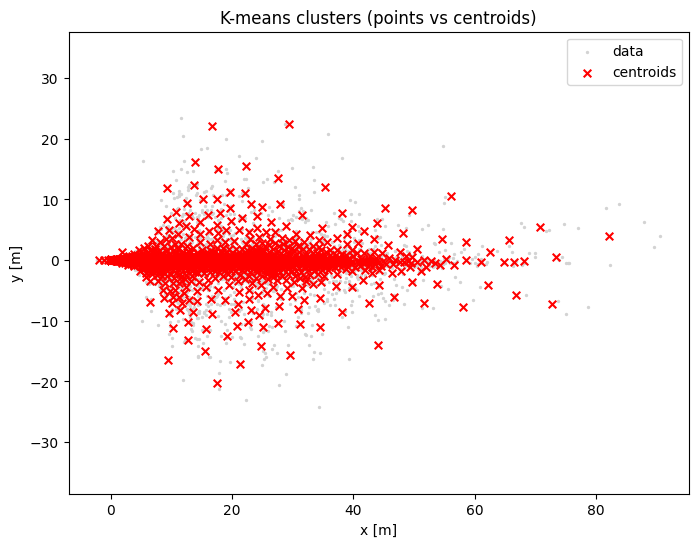

In [26]:
plot_kmeans_points(np.array(all_xy), codebook)

In [ ]:
def vq_encode_point(x, y, codebook):  # codebook: [K, 2]
    # Find nearest by Euclidean distance
    dif = codebook - np.array([x, y])[None, :]
    gid = np.argmin((dif**2).sum(axis=1))
    return int(gid)

# Encode trajectory as token sequence (with specials)
BOS, EOS, PAD, MASK = range(len(codebook), len(codebook)+4)

def encode_traj_xy(xy_list, codebook):
    ids = [BOS] + [vq_encode_point(x, y, codebook) for (x,y) in xy_list] + [EOS]
    return ids

In [ ]:
import math, torch, torch.nn as nn, torch.nn.functional as F

def normalize_xy_to_unit(xy: torch.Tensor):
    # xy: [N, 2]
    x_min, x_max = xy[:,0].min(), xy[:,0].max()
    y_min, y_max = xy[:,1].min(), xy[:,1].max()
    u = (xy[:,0] - x_min) / (x_max - x_min + 1e-6) * 2 - 1
    v = (xy[:,1] - y_min) / (y_max - y_min + 1e-6) * 2 - 1
    return torch.stack([u, v], dim=1)

def fourier_features_uv(uv: torch.Tensor, L: int):
    # uv: [N, 2] in [-1,1]
    N = uv.size(0)
    feats = []
    u, v = uv[:,0], uv[:,1]
    for k in range(L):
        w = math.pi * (2**k)
        feats += [torch.sin(w*u), torch.cos(w*u), torch.sin(w*v), torch.cos(w*v)]
    Fuv = torch.stack(feats, dim=1)  # [N, 4L]
    return Fuv

class FourierEmbInit(nn.Module):
    def __init__(self, fourier_L=64, D=4096):
        super().__init__()
        self.L = fourier_L
        self.D = D
        self.proj = nn.Linear(4*fourier_L, D, bias=True)
        # init: orthogonal or xavier
        nn.init.orthogonal_(self.proj.weight)  # good for tall matrices
        nn.init.zeros_(self.proj.bias)

    @torch.no_grad()
    def forward(self, anchor_xy: torch.Tensor):
        uv = normalize_xy_to_unit(anchor_xy)          # [Na,2]
        Fuv = fourier_features_uv(uv, self.L).to(anchor_xy.device)  # [Na, 4L]
        E_init = self.proj(Fuv)                       # [Na, D=4096]
        return E_init

# Usage
# anchors_idx = kmeans_on_centers(codebook, k=100)  # or farthest_point_sampling
# anchor_xy = codebook[anchors_idx]  # (100, 2)
# init_module = FourierEmbInit(fourier_L=64, D=4096)
# E_anchor_init = init_module(anchor_xy)               # [100, 4096]


In [ ]:
import numpy as np

def select_anchors_kmeans(centers_xy: np.ndarray, k: int = 100, seed: int = 42):
    """
    centers_xy: (N,2) float array, 2048 centers
    Returns: anchors_idx: (k,) int indices, pointing to rows in original centers_xy selected as anchors
    """
    try:
        from sklearn.cluster import MiniBatchKMeans
    except ImportError as e:
        raise RuntimeError("scikit-learn not installed, use select_anchors_fps or install sklearn first") from e

    N = centers_xy.shape[0]
    assert centers_xy.ndim == 2 and centers_xy.shape[1] == 2 and N >= k

    # 1) Apply KMeans(k=100) on centers
    kmeans = MiniBatchKMeans(
        n_clusters=k, batch_size=min(4096, N), n_init="auto",
        random_state=seed, max_iter=300, verbose=0
    )
    kmeans.fit(centers_xy)
    centroids = kmeans.cluster_centers_   # (k,2)

    # 2) 把每个质心用“最近的原始中心”替代（取其索引）
    #    这样得到的就是 codebook 中真实存在的 100 个点
    #    距离矩阵 D: (k, N) 可能较大，但k=100, N=2048没问题
    dif = centroids[:, None, :] - centers_xy[None, :, :]   # (k, N, 2)
    dist2 = np.einsum('knd,knd->kn', dif, dif)             # (k, N)
    nearest = dist2.argmin(axis=1)                         # (k,)

    # 3) Remove duplicates (very few centroids might point to the same center)
    anchors_idx = np.unique(nearest)
    if anchors_idx.shape[0] < k:
        # If not enough k, supplement with some farthest points (use FPS to fill)
        need = k - anchors_idx.shape[0]
        remain_mask = np.ones(N, dtype=bool)
        remain_mask[anchors_idx] = False
        extra = select_anchors_fps(centers_xy[remain_mask], need, seed)
        # Convert relative indices to absolute
        extra_abs = np.where(remain_mask)[0][extra]
        anchors_idx = np.concatenate([anchors_idx, extra_abs])
    return anchors_idx

In [4]:
# anchor_xy.tolist()
import numpy as np
codebook = np.load("codebook_xy_k2048.npy")

In [9]:
import torch
centers_xy = codebook
anchors_idx = select_anchors_kmeans(centers_xy, k=100, seed=42)

anchor_xy = torch.from_numpy(centers_xy[anchors_idx]).type(torch.float32)  # (100,2)


init_module = FourierEmbInit(fourier_L=64, D=4096)
E_anchor_init = init_module(anchor_xy)               # [100, 4096]


[200] total=0.04746 reg=0.00000 pair=4.74611
[400] total=0.04406 reg=0.00000 pair=4.40581
[600] total=0.03837 reg=0.00000 pair=3.83708


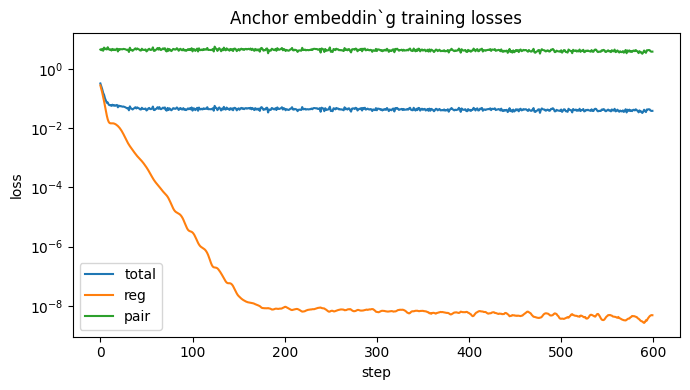

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import math, matplotlib.pyplot as plt

torch.manual_seed(0)

# ---- Your module (unchanged) ----
class AnchorGeomLearner(nn.Module):
    def __init__(self, D=4096, init_E_anchor=None):
        super().__init__()
        Na = init_E_anchor.size(0)
        self.E = nn.Parameter(init_E_anchor.clone())     # [Na,D]
        self.W = nn.Linear(D, 2, bias=True)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)

    def forward(self):
        E = self.E
        uv_hat = self.W(E)
        return E, uv_hat

# ---- 更稳的 pairwise：用“平方距离”，加尺度对齐 ----
@torch.no_grad()
def robust_scales(E, uv, num_pairs=4096):
    N = E.size(0)
    i = torch.randint(0, N, (num_pairs,), device=E.device)
    j = torch.randint(0, N, (num_pairs,), device=E.device)
    dE2  = (E[i]-E[j]).pow(2).sum(-1)          # squared dist
    duv2 = (uv[i]-uv[j]).pow(2).sum(-1)
    sE   = torch.quantile(dE2, 0.5) + 1e-8     # median scale
    suv  = torch.quantile(duv2, 0.5) + 1e-8
    return sE, suv

def pairwise_geom_loss_sq(E, uv, alpha=1.0, num_pairs=4096, sE=None, suv=None):
    N = E.size(0)
    i = torch.randint(0, N, (num_pairs,), device=E.device)
    j = torch.randint(0, N, (num_pairs,), device=E.device)
    dE2  = (E[i]-E[j]).pow(2).sum(-1)
    duv2 = (uv[i]-uv[j]).pow(2).sum(-1)
    if sE is not None and suv is not None:
        dE2  = dE2  / sE
        duv2 = duv2 / suv
    return ((dE2 - alpha*duv2)**2).mean()

# ---- Normalize to [-1,1] (safe version, avoid division by 0) ----
def normalize_xy_to_unit_safe(xy: torch.Tensor):
    x = xy[:,0]; y = xy[:,1]
    x_range = (x.max()-x.min()).clamp_min(1e-6)
    y_range = (y.max()-y.min()).clamp_min(1e-6)
    u = (x - x.min())/x_range * 2 - 1
    v = (y - y.min())/y_range * 2 - 1
    return torch.stack([u, v], dim=1)

# ====== Training ======
device = "cuda" if torch.cuda.is_available() else "cpu"

# Assuming we already have anchor_xy, E_anchor_init
anchor_xy = anchor_xy.to(device)                 # [100,2]
E_anchor_init = E_anchor_init.to(device)         # [100,4096]
uv_anchor = normalize_xy_to_unit_safe(anchor_xy) # [100,2]

model = AnchorGeomLearner(D=4096, init_E_anchor=E_anchor_init).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-6)  # Slightly lower LR/WDecay for stability
scalerE, scalerUV = robust_scales(E_anchor_init, uv_anchor, num_pairs=2048)

total_hist, reg_hist, pair_hist = [], [], []

torch.autograd.set_detect_anomaly(True)

for step in range(600):
    E, uv_hat = model()

    # Main regression loss
    loss_reg  = F.mse_loss(uv_hat, uv_anchor)

    # Pairwise (squared distance + scale alignment)
    loss_pair = pairwise_geom_loss_sq(E, uv_anchor, alpha=1.0,
                                      num_pairs=2048, sE=scalerE, suv=scalerUV)
    loss = loss_reg + 0.01*loss_pair + 1e-6*(E**2).mean()

    # Backward + gradient clipping
    opt.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()

    # NaN monitoring
    if not torch.isfinite(loss):
        print(f"[!] NaN at step {step}: reg={loss_reg.item():.4g} pair={loss_pair.item():.4g}")
        break

    # Record
    total_hist.append(loss.item())
    reg_hist.append(loss_reg.item())
    pair_hist.append(loss_pair.item())

    if (step+1) % 200 == 0:
        print(f"[{step+1}] total={loss.item():.5f} reg={loss_reg.item():.5f} pair={loss_pair.item():.5f}")

# ====== Visualization ======
plt.figure(figsize=(7,4))
plt.plot(total_hist, label="total")
plt.plot(reg_hist,   label="reg")
plt.plot(pair_hist,  label="pair")
plt.yscale("log")              # Log scale for clearer visualization
plt.xlabel("step"); plt.ylabel("loss")
plt.legend(); plt.title("Anchor embeddin`g training losses")
plt.tight_layout(); plt.show()


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def knn_rbf_interpolate_to_full(
    centers_xy: torch.Tensor,       # [N,2] = [2048,2]
    anchors_idx: torch.Tensor,      # [Na]  = [100]
    E_anchor: torch.Tensor,         # [Na,D]
    k: int = 6,                     # Number of neighbors (4~8 are fine)
    sigma: float = None,            # RBF width; auto-estimate when None
    smoothing_iters: int = 0,       # Laplacian smoothing iteration count (0 means no smoothing)
    smoothing_k: int = 8,           # kNN for smoothing
    smoothing_lambda: float = 0.5,  # Smoothing mixing coefficient
):
    """
    Returns:
      E_full: [N, D], containing embeddings for 2048 centers (anchors=learned, non-anchors=interpolated/smoothed)
    """
    device = E_anchor.device
    centers_xy = centers_xy.to(device)
    anchors_idx = anchors_idx.to(device)

    N = centers_xy.size(0)
    Na = anchors_idx.numel()
    D = E_anchor.size(1)

    # 1) Prepare mask / indices
    anchors_mask = torch.zeros(N, dtype=torch.bool, device=device)
    anchors_mask[anchors_idx] = True
    non_idx = torch.nonzero(~anchors_mask, as_tuple=False).squeeze(1)  # [N-Na]

    # 2) Precompute distances between anchors and all points (coordinate space)
    #    First find the nearest k anchors for each point
    #    Distance matrix: [N, Na]
    dist_N_Na = torch.cdist(centers_xy, centers_xy[anchors_idx])  # [N, Na]
    # Take the first k nearest anchors
    k_eff = min(k, Na)
    dvals, didxs = torch.topk(-dist_N_Na, k_eff, dim=1)  # Largest negative distance = smallest distance
    dsel = -dvals                                       # [N, k_eff] positive distance
    nbr_idx = anchors_idx[didxs]                        # [N, k_eff] → global indices (2048 range)

    # 3) Estimate sigma (if not given): use median of nearest neighbor distances between anchors
    if sigma is None:
        # Anchor-anchor distance, ignore self
        dAA = torch.cdist(centers_xy[anchors_idx], centers_xy[anchors_idx])
        dAA = dAA + torch.eye(Na, device=device) * 1e9
        sigma = torch.median(torch.min(dAA, dim=1).values).clamp_min(1e-6).item()

    # 4) RBF weights and weighted average (non-anchors)
    w = torch.exp(-(dsel**2) / (sigma**2 + 1e-12))      # [N, k_eff]
    w = w / (w.sum(dim=1, keepdim=True) + 1e-12)

    E_full = torch.empty(N, D, device=device,dtype=torch.float32)
    # First put anchors directly
    E_full[anchors_idx] = E_anchor
    # Calculate weighted average for all points (including anchors) first
    E_interp_all = (w.unsqueeze(-1) * E_full[nbr_idx]).sum(dim=1) .to(torch.float32) # Here anchor rows will use E_full[nbr_idx], but anchor rows will be overwritten later

    # Only write to non-anchors (anchors keep trained values)
    
    E_full[non_idx] = E_interp_all[non_idx]

    # 5) (Optional) Laplacian smoothing (anchors fixed)
    if smoothing_iters > 0:
        # Build kNN for all 2048 points (coordinate space)
        Dxy_all = torch.cdist(centers_xy, centers_xy) + torch.eye(N, device=device) * 1e9
        nbr_all = torch.topk(-Dxy_all, smoothing_k, dim=1).indices  # [N, k]
        for _ in range(smoothing_iters):
            neigh_mean = E_full[nbr_all].mean(dim=1)   # [N, D]
            E_full[~anchors_mask] = (
                (1.0 - smoothing_lambda) * E_full[~anchors_mask]
                + smoothing_lambda * neigh_mean[~anchors_mask]
            )

    return E_full


In [21]:
E_anchor_init.shape

torch.Size([100, 4096])

In [ ]:
# Already have:
# centers_xy   : [2048,2]  (float, meters)
# anchors_idx  : [100]
# E_anchor     : [100,4096]  # Trained anchor embeddings

E_full = knn_rbf_interpolate_to_full(
    centers_xy=centers_xy,
    anchors_idx=anchors_idx,
    E_anchor=E_anchor_init,
    k=6,                     # Number of neighbors
    sigma=None,              # Auto-estimate
    smoothing_iters=6,       # Laplacian smoothing steps (can try 0 or 5~10 first)
    smoothing_k=8,
    smoothing_lambda=0.5,
)  # -> [2048, 4096]

# Concatenate special tokens
V = 2048 + 4
BOS, EOS, PAD, MASK = 2048, 2049, 2050, 2051
E_weight = torch.empty(V, 4096, device=E_full.device)
E_weight[:2048] = E_full
torch.nn.init.normal_(E_weight[BOS], std=1e-3)
torch.nn.init.normal_(E_weight[EOS], std=1e-3)
E_weight[PAD].zero_()
torch.nn.init.normal_(E_weight[MASK], std=1e-3)

# Save for LLaDA nn.Embedding initialization
torch.save({"embedding_weight": E_weight.cpu()}, "embedding_init_D4096.pt")
print("Saved -> embedding_init_D4096.pt")


Saved -> embedding_init_D4096.pt


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F

# ---------- utils ----------
def normalize_xy_to_unit_safe(xy: torch.Tensor):
    x, y = xy[:,0], xy[:,1]
    xr = (x.max()-x.min()).clamp_min(1e-6)
    yr = (y.max()-y.min()).clamp_min(1e-6)
    u = (x - x.min())/xr * 2 - 1
    v = (y - y.min())/yr * 2 - 1
    return torch.stack([u, v], dim=1)

@torch.no_grad()
def robust_scales(E, uv, pairs=4096):
    N = E.size(0)
    i = torch.randint(0, N, (pairs,), device=E.device)
    j = torch.randint(0, N, (pairs,), device=E.device)
    dE2  = (E[i]-E[j]).pow(2).sum(-1)
    duv2 = (uv[i]-uv[j]).pow(2).sum(-1)
    sE  = torch.quantile(dE2, 0.5) + 1e-8
    suv = torch.quantile(duv2, 0.5) + 1e-8
    return sE, suv

def pairwise_loss_sq(E, uv, pairs=4096, alpha=1.0, sE=None, suv=None, idx=None):
    # If idx is provided, only do pairwise on subset (more computationally efficient)
    if idx is not None:
        E  = E[idx]
        uv = uv[idx]
    N = E.size(0)
    i = torch.randint(0, N, (pairs,), device=E.device)
    j = torch.randint(0, N, (pairs,), device=E.device)
    dE2  = (E[i]-E[j]).pow(2).sum(-1)
    duv2 = (uv[i]-uv[j]).pow(2).sum(-1)
    if sE is not None and suv is not None:
        dE2  = dE2 / sE
        duv2 = duv2 / suv
    return ((dE2 - alpha*duv2)**2).mean()

# ---------- model ----------
class FullGeomLearner(nn.Module):
    def __init__(self, init_E_full, D=4096):
        super().__init__()
        N, D0 = init_E_full.shape
        assert D0 == D
        self.E = nn.Parameter(init_E_full.clone())   # [N, D]
        self.ln = nn.LayerNorm(D)                    # More stable for large dimensions: LayerNorm before regression
        self.W  = nn.Linear(D, 2, bias=True)
        nn.init.xavier_uniform_(self.W.weight); nn.init.zeros_(self.W.bias)

    def forward(self, idx=None):
        if idx is None:
            E = self.E
        else:
            E = self.E[idx]
        uv_hat = self.W(self.ln(E))
        return E, uv_hat

# ---------- training (Phase-1 & Phase-2) ----------
def train_full_embeddings(
    centers_xy,             # [2048,2] float
    anchors_idx,            # [100] long
    E_full_init,            # [2048,4096] (interpolated/smoothed initialization)
    steps_phase1=2000,      # Only train non-anchors
    steps_phase2=2000,      # Full fine-tuning
    batch_size=512,         # Index sampling training
    lr1=3e-4, lr2=2e-4,
    wd=1e-6,
    pair_w=0.002,             # Pairwise loss weight (adjust between 0.1~0.5)
    lap_w=0.0,              # Can be set >0 to add graph smoothing regularization (lightweight)
    knn_k=8,                # k for graph smoothing
    seed=0, device="cuda",
):
    torch.manual_seed(seed)
    centers_xy = centers_xy.to(device)
    anchors_idx = anchors_idx.to(device)
    uv_all = normalize_xy_to_unit_safe(centers_xy)         # [N,2]

    N, D = E_full_init.shape
    model = FullGeomLearner(E_full_init.to(device), D=D).double().to(device)

    anchors_mask = torch.zeros(N, dtype=torch.bool, device=device)
    anchors_mask[anchors_idx] = True
    non_idx = torch.nonzero(~anchors_mask, as_tuple=False).squeeze(1)

    # Precompute pairwise scales
    with torch.no_grad():
        sE, suv = robust_scales(model.E.data, uv_all, pairs=4096)

    # (Optional) Prepare graph smoothing adjacency (coordinate space kNN)
    if lap_w > 0.0:
        with torch.no_grad():
            Dxy = torch.cdist(centers_xy, centers_xy) + torch.eye(N, device=device)*1e9
            nbr = torch.topk(-Dxy, knn_k, dim=1).indices  # [N,k]

    def laplacian_penalty(E):
        # L2 to neighbor mean
        neigh_mean = E[nbr].mean(dim=1)            # [N,D]
        return (E - neigh_mean).pow(2).sum(dim=1).mean()
    
    # === Loss history ===
    total_hist, reg_hist, pair_hist = [], [], []

    # ------------ Phase-1: freeze anchors ------------
    opt = torch.optim.Adam(model.parameters(), lr=lr1, weight_decay=wd)
    for step in range(steps_phase1):
        # Sample a batch of non-anchors
        idx = non_idx[torch.randint(0, non_idx.numel(), (batch_size,), device=device)]
        E_b, uv_hat = model(idx)

        # reg
        reg = F.mse_loss(uv_hat, uv_all[idx])

        # Pairwise on batch (more computationally efficient; if more complete needed, don't pass idx)
        pair = pairwise_loss_sq(model.E, uv_all, pairs=2048, alpha=1.0, sE=sE, suv=suv, idx=idx)

        loss = 0.7*reg + pair_w*pair  # Slightly smaller reg weight to prevent oscillation
        # loss.to(torch.float32)
        if lap_w > 0.0:
            loss = loss + lap_w * laplacian_penalty(model.E)
            # loss.to(torch.float32)

        opt.zero_grad(set_to_none=True)
        # loss = loss.to(torch.float32)

        total_hist.append(float(loss.detach().cpu()))
        reg_hist.append(float(reg.detach().cpu()))
        pair_hist.append(float(pair.detach().cpu()))

        # print(loss.dtype)
        loss.backward()
        # Freeze anchors: zero out anchor gradients
        if model.E.grad is not None:
            model.E.grad[anchors_mask] = 0.0
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if (step+1) % 200 == 0:
            print(f"[P1 {step+1}] total={loss.item():.5e} reg={reg.item():.5e} pair={pair.item():.5e}")

    # ------------ Phase-2: unfreeze all ------------
    opt = torch.optim.Adam(model.parameters(), lr=lr2, weight_decay=wd)
    for step in range(steps_phase2):
        # Mixed sampling: some anchors + non-anchors (for overall alignment)
        n_anchor = batch_size // 4
        idx_a = anchors_idx[torch.randint(0, anchors_idx.numel(), (n_anchor,), device=device)]
        idx_b = non_idx[torch.randint(0, non_idx.numel(), (batch_size - n_anchor,), device=device)]
        idx = torch.cat([idx_a, idx_b], dim=0)

        E_b, uv_hat = model(idx)
        reg = F.mse_loss(uv_hat, uv_all[idx])
        pair = pairwise_loss_sq(model.E, uv_all, pairs=2048, alpha=1.0, sE=sE, suv=suv, idx=idx)

        loss = 0.7*reg + pair_w*pair
        if lap_w > 0.0:
            loss = loss + lap_w * laplacian_penalty(model.E)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_hist.append(float(loss.detach().cpu()))
        reg_hist.append(float(reg.detach().cpu()))
        pair_hist.append(float(pair.detach().cpu()))

        if (step+1) % 200 == 0:
            print(f"[P2 {step+1}] total={loss.item():.5e} reg={reg.item():.5e} pair={pair.item():.5e}")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,4))
    plt.plot(total_hist, label="total")
    plt.plot(reg_hist,   label="reg")
    plt.plot(pair_hist,  label="pair")
    plt.yscale("log")
    plt.xlabel("step"); plt.ylabel("loss")
    plt.title("Anchor-expanded 2048 embedding training losses")
    plt.legend()
    plt.tight_layout()
    return model.E.data.detach()  # [2048,4096]


[P1 200] total=2.82062e-02 reg=3.96091e-02 pair=9.59574e+00
[P1 400] total=1.41392e-02 reg=1.91482e-02 pair=1.47094e+01
[P1 600] total=1.19388e-02 reg=1.55051e-02 pair=2.17052e+01
[P1 800] total=8.11903e-03 reg=1.04939e-02 pair=1.54658e+01
[P1 1000] total=1.20772e-02 reg=1.66847e-02 pair=7.95925e+00
[P1 1200] total=1.00152e-02 reg=1.28131e-02 pair=2.09193e+01
[P1 1400] total=7.32282e-03 reg=9.51526e-03 pair=1.32427e+01
[P1 1600] total=4.91167e-03 reg=6.38663e-03 pair=8.82055e+00
[P1 1800] total=5.19209e-03 reg=6.48986e-03 pair=1.29836e+01
[P1 2000] total=4.90155e-03 reg=6.29546e-03 pair=9.89458e+00
[P1 2200] total=3.34195e-03 reg=4.02582e-03 pair=1.04776e+01
[P1 2400] total=4.14626e-03 reg=5.21952e-03 pair=9.85190e+00
[P1 2600] total=3.90439e-03 reg=4.66129e-03 pair=1.28297e+01
[P1 2800] total=3.21681e-03 reg=4.08586e-03 pair=7.13427e+00
[P1 3000] total=5.44080e-03 reg=6.92180e-03 pair=1.19107e+01
[P1 3200] total=3.51859e-03 reg=4.20782e-03 pair=1.14623e+01
[P1 3400] total=3.31631e-03 

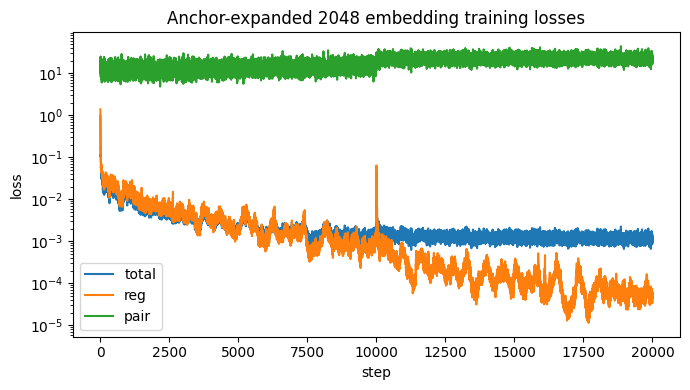

In [ ]:
# 假设你已经得到：
# centers_xy   : [2048,2] (float, meters)
# anchors_idx  : [100]    (long)
# E_full_init  : [2048,4096]  # 由“100点训好 + kNN-RBF 插值(+平滑)”得到
device = "cuda" if torch.cuda.is_available() else "cpu"

state = torch.load("embedding_init_D4096.pt")
E_full_init = state["embedding_weight"][:2048].to(device)   # [2048, 4096]

device = "cuda" if torch.cuda.is_available() else "cpu"
E_full_trained = train_full_embeddings(
    torch.from_numpy(centers_xy), torch.from_numpy(anchors_idx), E_full_init,
    steps_phase1=10000, steps_phase2=10000,
    batch_size=512, lr1=3e-4, lr2=2e-4,
    pair_w=0.00005, lap_w=0.0, knn_k=8, device=device
)

# Concatenate special tokens and save for LLaDA nn.Embedding initialization
V = 2048 + 4
BOS, EOS, PAD, MASK = 2048, 2049, 2050, 2051
E_weight = torch.empty(V, 4096, device=device)
E_weight[:2048] = E_full_trained
torch.nn.init.normal_(E_weight[BOS], std=1e-3)
torch.nn.init.normal_(E_weight[EOS], std=1e-3)
E_weight[PAD].zero_()
torch.nn.init.normal_(E_weight[MASK], std=1e-3)
torch.save({"embedding_weight": E_weight.cpu()}, "embedding_trained_D4096.pt")
print("Saved -> embedding_trained_D4096.pt")




NameError: name 'total_hist' is not defined

<Figure size 700x400 with 0 Axes>